# Myanmar Handwriting Recognition

## Feature Embedding Summary

Instead of training directly from raw stroke coordinates, this project uses **extracted and embedded stroke-level features** as input to the machine learning models.

Each handwriting sample is represented as a sequence of stroke embeddings, where each embedding captures the local shape and motion characteristics of a stroke segment in a compact vector form. This representation provides two main benefits:

1. **Dimensionality reduction and normalization**  
   Raw handwriting signals can be noisy and variable in length. Embedding converts them into a cleaner and more compact representation.

2. **Better sequence learning**  
   Once the strokes are converted into embeddings, sequence models can focus on learning the relationships between meaningful handwriting units rather than dealing directly with raw coordinates.

As a result, the embedding layer acts as a strong intermediate representation between raw handwriting input and downstream recognition models.

### DataSet Loading
Strokes ( series of x, y, timestamp ) infromation are load to Pandas Dataframe.

In [1]:
# @title Load Dataset
from load_dataset import get_syllable_df, load_all_strokes, build_train_df

syl_path = '../syl.txt'
hw_path = '../dataset/Aung_Hein/'

processed_df, syllable_df, stroke_df, char2idx, idx2char = build_train_df(syl_path, hw_path)
processed_df['sample_index'] = processed_df.index

### Preview

In [2]:
processed_df[processed_df.char_array.apply(lambda x : True if 'မ' in x else False )]

,id,sample_id,strokes,num_strokes,max_stroke_len,total_points,source_file,syllable,num_char,char_array,padded_chars,encoded,mask,sample_index
3,2,1,"[[[131.0, 141.0, 1775179462.936], [131.0, 141....",2,37,49,../dataset/Aung_Hein/2-1.txt,မ,1,[မ],"[မ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, ...","[26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",3
4,2,2,"[[[131.0, 144.0, 1775179465.373], [130.0, 143....",2,29,51,../dataset/Aung_Hein/2-2.txt,မ,1,[မ],"[မ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, ...","[26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",4
5,2,3,"[[[104.0, 155.0, 1775179467.955], [104.0, 155....",2,28,45,../dataset/Aung_Hein/2-3.txt,မ,1,[မ],"[မ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, ...","[26, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",5
21,8,1,"[[[75.0, 186.0, 1775179564.882], [73.0, 186.0,...",3,41,73,../dataset/Aung_Hein/8-1.txt,မှာ,3,"[မ, ှ, ာ]","[မ, ှ, ာ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <...","[26, 58, 43, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",21
22,8,2,"[[[57.0, 185.0, 1775179569.229], [56.0, 186.0,...",3,39,85,../dataset/Aung_Hein/8-2.txt,မှာ,3,"[မ, ှ, ာ]","[မ, ှ, ာ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <...","[26, 58, 43, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13208,4413,2,"[[[76.0, 207.0, 1777306389.339], [75.0, 207.0,...",6,30,93,../dataset/Aung_Hein/4413-2.txt,မိင်း,5,"[မ, ိ, င, ်, း]","[မ, ိ, င, ်, း, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[26, 44, 5, 54, 52, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13208
13209,4413,3,"[[[71.0, 214.0, 1777306395.719], [70.0, 214.0,...",6,34,107,../dataset/Aung_Hein/4413-3.txt,မိင်း,5,"[မ, ိ, င, ်, း]","[မ, ိ, င, ်, း, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[26, 44, 5, 54, 52, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13209
13210,4413,4,"[[[64.0, 192.0, 1777306403.337], [64.0, 192.0,...",6,29,95,../dataset/Aung_Hein/4413-4.txt,မိင်း,5,"[မ, ိ, င, ်, း]","[မ, ိ, င, ်, း, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[26, 44, 5, 54, 52, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13210
13211,4413,5,"[[[66.0, 198.0, 1777306413.6], [66.0, 198.0, 1...",6,34,103,../dataset/Aung_Hein/4413-5.txt,မိင်း,5,"[မ, ိ, င, ်, း]","[မ, ိ, င, ်, း, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[26, 44, 5, 54, 52, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13211


In [3]:
processed_df[processed_df.char_array.apply(lambda x : True if 'ပ' in x else False )]

,id,sample_id,strokes,num_strokes,max_stroke_len,total_points,source_file,syllable,num_char,char_array,padded_chars,encoded,mask,sample_index
12,5,1,"[[[80.0, 233.0, 1775179486.436], [79.0, 234.0,...",3,24,52,../dataset/Aung_Hein/5-1.txt,ပါ,2,"[ပ, ါ]","[ပ, ါ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD...","[22, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",12
13,5,2,"[[[106.0, 243.0, 1775179489.213], [106.0, 243....",3,26,55,../dataset/Aung_Hein/5-2.txt,ပါ,2,"[ပ, ါ]","[ပ, ါ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD...","[22, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",13
14,5,3,"[[[92.0, 270.0, 1775179491.801], [92.0, 270.0,...",3,27,54,../dataset/Aung_Hein/5-3.txt,ပါ,2,"[ပ, ါ]","[ပ, ါ, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>, <PAD...","[22, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",14
87,30,1,"[[[137.0, 193.0, 1775179826.901], [137.0, 193....",6,35,92,../dataset/Aung_Hein/30-1.txt,ပြီး,4,"[ပ, ြ, ီ, း]","[ပ, ြ, ီ, း, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>...","[22, 56, 45, 52, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",87
88,30,2,"[[[132.0, 212.0, 1775179830.06], [131.0, 214.0...",6,35,104,../dataset/Aung_Hein/30-2.txt,ပြီး,4,"[ပ, ြ, ီ, း]","[ပ, ြ, ီ, း, <PAD>, <PAD>, <PAD>, <PAD>, <PAD>...","[22, 56, 45, 52, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13190,4407,2,"[[[35.0, 216.0, 1777306256.896], [34.0, 216.0,...",7,29,143,../dataset/Aung_Hein/4407-2.txt,ပတ်ခ်,5,"[ပ, တ, ်, ခ, ်]","[ပ, တ, ်, ခ, ်, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[22, 17, 54, 2, 54, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13190
13191,4407,3,"[[[45.0, 213.0, 1777306264.479], [45.0, 213.0,...",7,29,145,../dataset/Aung_Hein/4407-3.txt,ပတ်ခ်,5,"[ပ, တ, ်, ခ, ်]","[ပ, တ, ်, ခ, ်, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[22, 17, 54, 2, 54, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13191
13192,4408,1,"[[[35.0, 243.0, 1777306272.309], [35.0, 242.0,...",6,42,127,../dataset/Aung_Hein/4408-1.txt,ပေ့စ်,5,"[ပ, ေ, ့, စ, ်]","[ပ, ေ, ့, စ, ်, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[22, 48, 51, 6, 54, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13192
13193,4408,2,"[[[56.0, 246.0, 1777306279.67], [56.0, 245.0, ...",6,39,124,../dataset/Aung_Hein/4408-2.txt,ပေ့စ်,5,"[ပ, ေ, ့, စ, ်]","[ပ, ေ, ့, စ, ်, <PAD>, <PAD>, <PAD>, <PAD>, <P...","[22, 48, 51, 6, 54, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]",13193


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/mm/Pyidaungsu-2.3_Regular.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()

## Feature Representation

In this project, each handwriting sample is represented using extracted stroke-level features before being used by the recognition models. The feature vector is organized into **12 feature groups**, where each group captures a different aspect of handwriting structure, movement, and spatial layout.

### 12 Feature Blocks

1. **geom**  
   Geometric features describing the shape, size, length, and spatial properties of the stroke or segment.

2. **pause**  
   Pause-related features that capture pen-up / temporal gap behavior between strokes or segments.

3. **turn**  
   Turning-related features that describe directional changes and corner-like motion patterns.

4. **progression**  
   Features describing how the writing progresses across the stroke sequence, such as relative movement and stroke development.

5. **zone_pct_cov**  
   Percentage coverage of writing across predefined spatial zones.

6. **zone_active**  
   Binary or compact indicators showing which spatial zones are active.

7. **line_rel**  
   Features describing the relationship of the stroke to writing lines or relative vertical positioning.

8. **dot**  
   Features for dot-like or small isolated stroke behavior, which can be important in Myanmar script.

9. **direction_hist**  
   Histogram-based directional distribution features summarizing stroke direction patterns.

10. **curvature_hist**  
    Histogram-based curvature features describing how much the stroke bends or curves.

11. **projection_hist**  
    Projection histogram features summarizing spatial density across horizontal and vertical directions.

12. **local_grid**  
    Fine-grained local spatial grid features capturing detailed local occupancy or structure.

### Why these features are useful

These 12 feature groups are designed to capture both:
- **local handwriting dynamics** (shape, turn, curvature, direction)
- **global structural layout** (zone coverage, projection, line relation, local grid)

This gives a rich representation of Myanmar handwriting while keeping the system efficient enough for CPU-only experiments.

In [5]:
from embedding import embed_stroke_dataframe, stack_embeddings

full_emb_df = embed_stroke_dataframe(processed_df)

In [6]:
from embedding import fit_pca_embedder,transform_with_embedder,stack_embeddings

X = stack_embeddings(full_emb_df)
y = full_emb_df["embedding_label"].values


Confusion analysis: ရ vs န
     feature_block  effect_size  dim
0             geom     4.435403   26
1     zone_pct_cov     3.830582    6
2  projection_hist     3.137997   16
3   curvature_hist     2.078929    8
4      progression     2.056571   12
5       local_grid     1.692113   52
6   direction_hist     1.664417    8
7      zone_active     1.308862    3
8         line_rel     1.178763    6
9              dot     1.023447   12


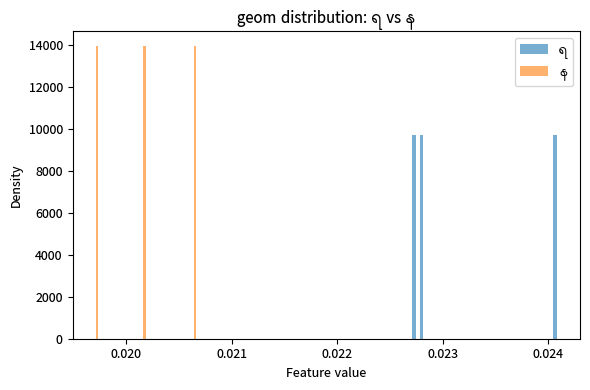

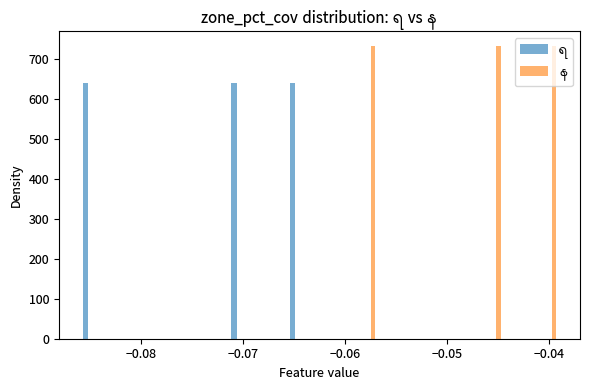

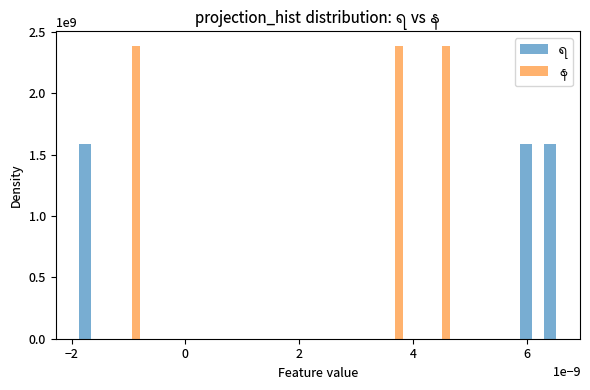

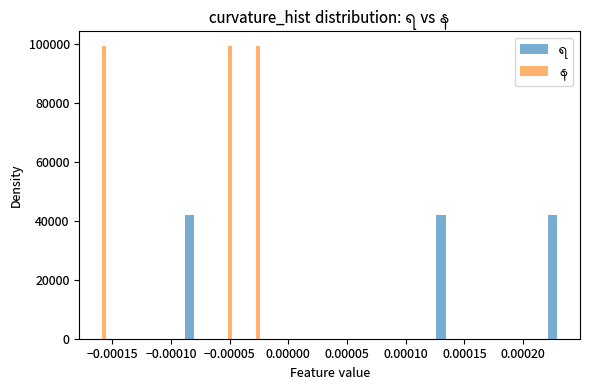

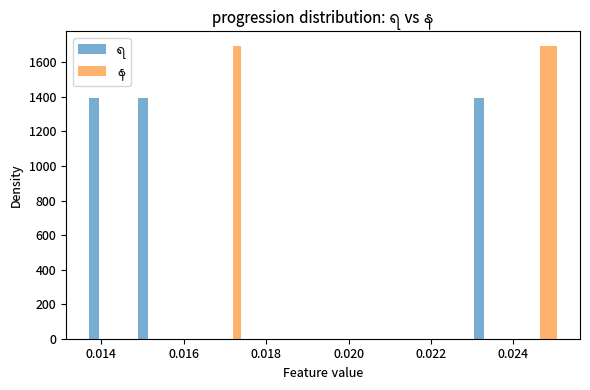

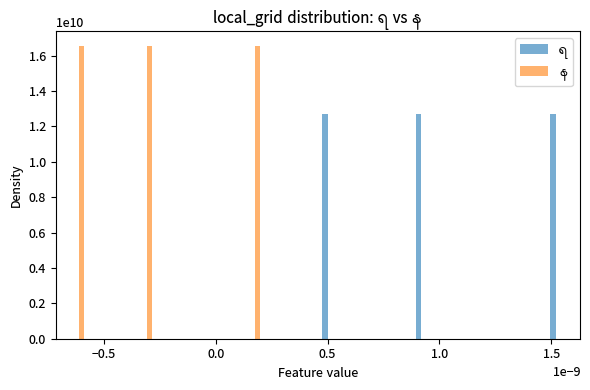

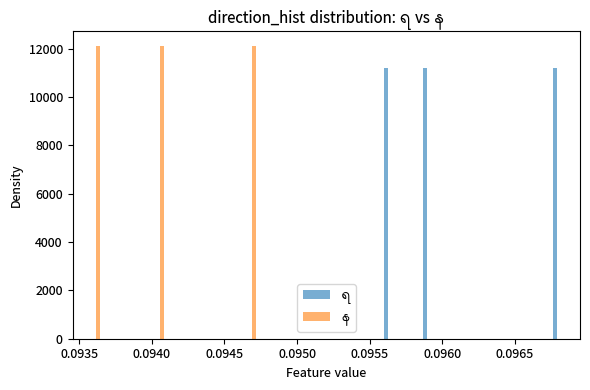

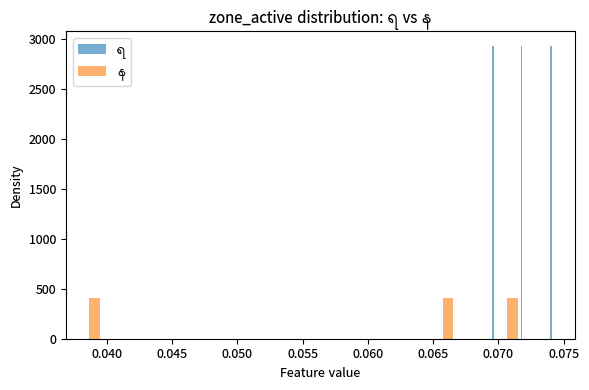

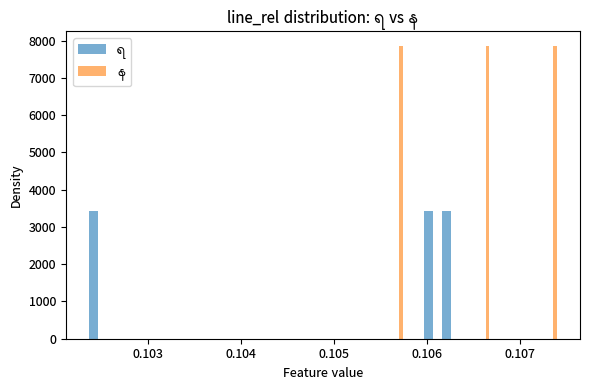

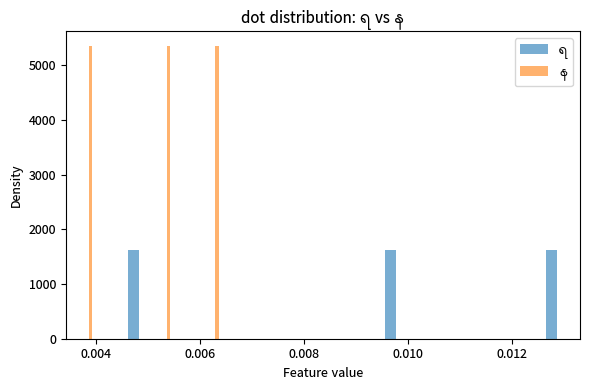

In [7]:
from stroke_confusion_analysis import analyze_confusion_pair

analyze_confusion_pair(
    full_emb_df,
    label_a="ရ",
    label_b="န",
    top_k=10,
)

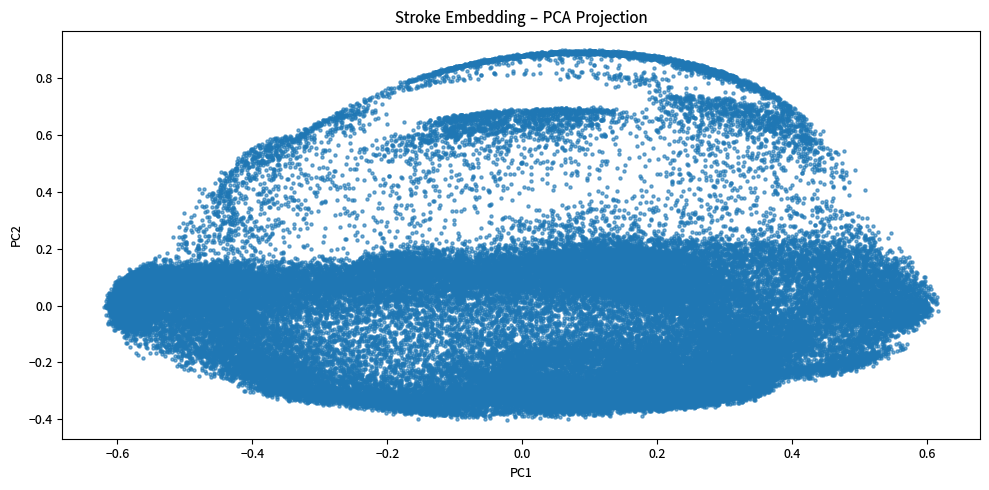

Explained variance: [0.22689895 0.1802934 ]


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.6)
plt.title("Stroke Embedding – PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)

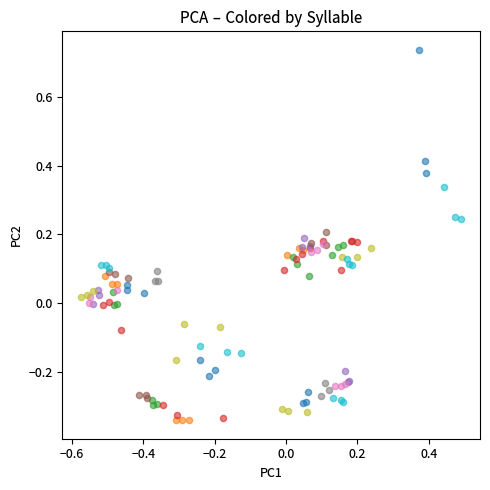

In [31]:
# attach labels (one per stroke, approximate)
label_df = (
    processed_df[["sample_index", "syllable"]]
    .drop_duplicates("sample_index")
)


vis_df = full_emb_df.merge(label_df, on="sample_index", how="left")

plt.figure(figsize=(5,5))
for syll, g in vis_df.groupby("syllable_x"):
    plt.scatter(
        X_pca[g.index,0],
        X_pca[g.index,1],
        s=20,
        alpha=0.6,
        label=syll
    )
    if len(plt.gca().get_legend_handles_labels()[1]) > 10:
        break

plt.title("PCA – Colored by Syllable")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

/home/kyalkalay/.config/jupyterlab-desktop/envs/Jupyterlab_Default/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


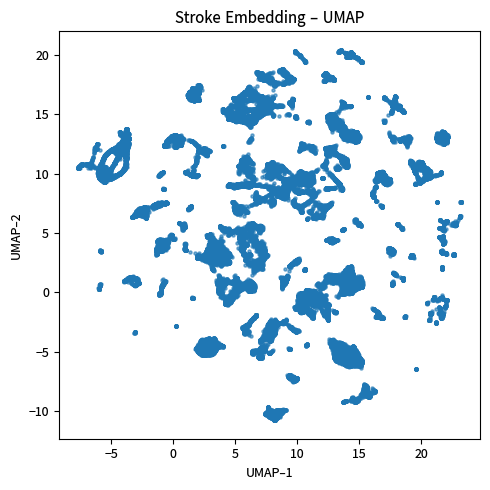

In [30]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(5,5))
plt.scatter(X_umap[:,0], X_umap[:,1], s=5, alpha=0.6)
plt.title("Stroke Embedding – UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

Cosine similarity (နု vs ခု): 0.8615


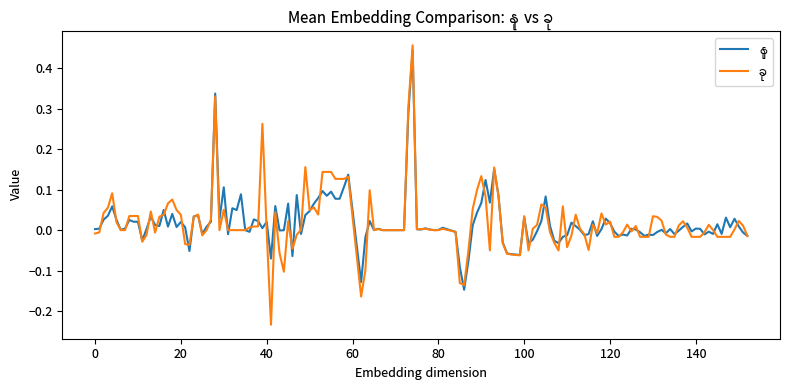

In [33]:
from embedding_visualization import compare_two_labels
compare_two_labels(
    full_emb_df,
    processed_df,
    label_col="syllable_x",
    label_a="နု",
    label_b="ခု",
)

Cosine similarity (အ vs န): 0.8836


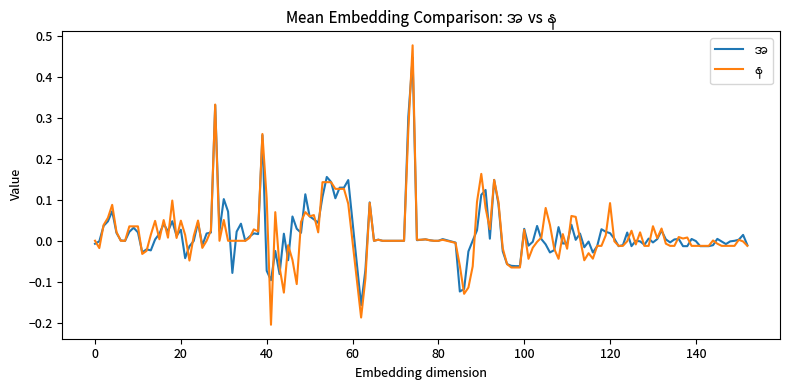

In [34]:
from embedding_visualization import compare_two_labels
compare_two_labels(
    full_emb_df,
    processed_df,
    label_col="syllable_x",
    label_a="အ",
    label_b="န",
)

Cosine similarity (ထ vs တ): 0.9108


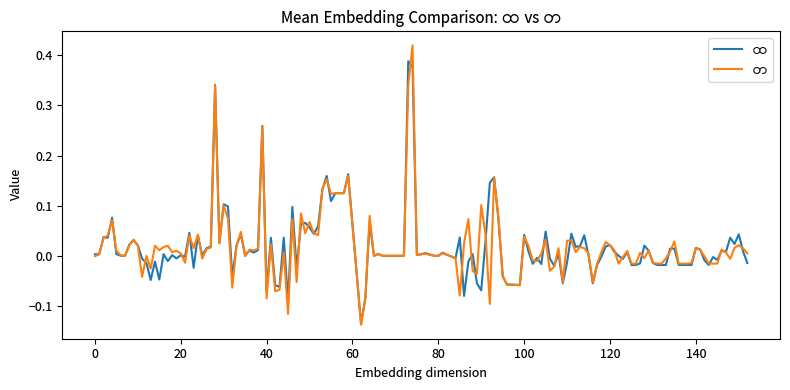

In [13]:
from embedding_visualization import compare_two_labels
compare_two_labels(
    full_emb_df,
    processed_df,
    label_col="syllable_x",
    label_a="ထ",
    label_b="တ",
)

In [14]:
full_emb_df[full_emb_df.syllable=='လေး']

,id,sample_id,strokes,num_strokes,max_stroke_len,total_points,source_file,syllable,num_char,char_array,...,stroke_order_label,stroke_struct_label,embedding_label,stroke_is_dot,stroke_dot_role,stroke_major_zone,stroke_active_zones,stroke_single_position,stroke_num_points,stroke_disp_angle
457,44,1,"[[[13.0, 334.0, 1775179973.766], [13.0, 333.0,...",5,25,63,../dataset/Aung_Hein/44-1.txt,လေး,3,"[လ, ေ, း]",...,လေး__s0,လေး__s0,လေး__s0,False,none,None,None,None,25,-0.821527
458,44,1,"[[[13.0, 334.0, 1775179973.766], [13.0, 333.0,...",5,25,63,../dataset/Aung_Hein/44-1.txt,လေး,3,"[လ, ေ, း]",...,လေး__s1,လေး__s1,လေး__s1,False,none,None,None,None,19,-0.105984
459,44,1,"[[[13.0, 334.0, 1775179973.766], [13.0, 333.0,...",5,25,63,../dataset/Aung_Hein/44-1.txt,လေး,3,"[လ, ေ, း]",...,လေး__s2,လေး__s2,လေး__s2,False,none,None,None,None,11,1.749891
460,44,1,"[[[13.0, 334.0, 1775179973.766], [13.0, 333.0,...",5,25,63,../dataset/Aung_Hein/44-1.txt,လေး,3,"[လ, ေ, း]",...,လေး__s3,လေး__s3,လေး__s3,False,none,None,None,None,4,1.570796
461,44,1,"[[[13.0, 334.0, 1775179973.766], [13.0, 333.0,...",5,25,63,../dataset/Aung_Hein/44-1.txt,လေး,3,"[လ, ေ, း]",...,လေး__s4,လေး__s4,လေး__s4,False,none,None,None,None,4,0.000000
462,44,2,"[[[45.0, 337.0, 1775179977.376], [45.0, 336.0,...",5,23,64,../dataset/Aung_Hein/44-2.txt,လေး,3,"[လ, ေ, း]",...,လေး__s0,လေး__s0,လေး__s0,False,none,None,None,None,23,-0.901984
463,44,2,"[[[45.0, 337.0, 1775179977.376], [45.0, 336.0,...",5,23,64,../dataset/Aung_Hein/44-2.txt,လေး,3,"[လ, ေ, း]",...,လေး__s1,လေး__s1,လေး__s1,False,none,None,None,None,22,0.081452
464,44,2,"[[[45.0, 337.0, 1775179977.376], [45.0, 336.0,...",5,23,64,../dataset/Aung_Hein/44-2.txt,လေး,3,"[လ, ေ, း]",...,လေး__s2,လေး__s2,လေး__s2,False,none,None,None,None,12,1.555413
465,44,2,"[[[45.0, 337.0, 1775179977.376], [45.0, 336.0,...",5,23,64,../dataset/Aung_Hein/44-2.txt,လေး,3,"[လ, ေ, း]",...,လေး__s3,လေး__s3,လေး__s3,False,none,None,None,None,4,1.325818
466,44,2,"[[[45.0, 337.0, 1775179977.376], [45.0, 336.0,...",5,23,64,../dataset/Aung_Hein/44-2.txt,လေး,3,"[လ, ေ, း]",...,လေး__s4,လေး__s4,လေး__s4,False,none,None,None,None,3,2.034444


Cosine similarity (စေး vs လေး): 0.9555


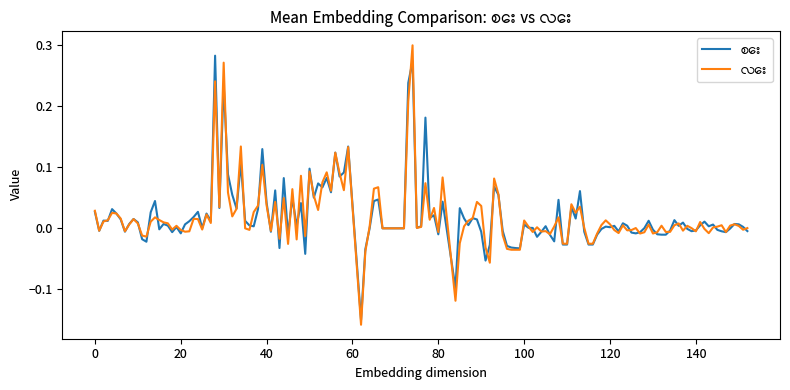

In [15]:
from embedding_visualization import compare_two_labels
compare_two_labels(
    full_emb_df,
    processed_df,
    label_col="syllable_x",
    label_a="စေး",
    label_b="လေး",
)

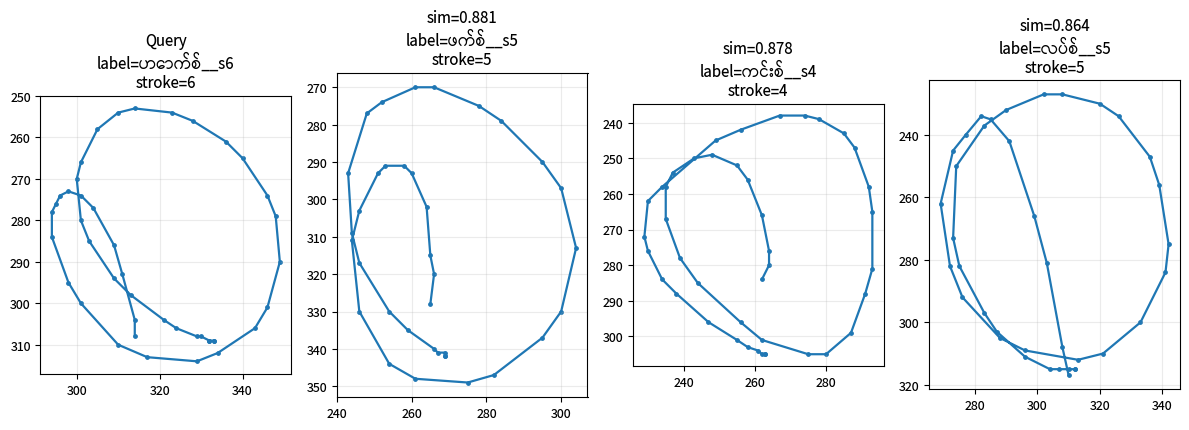

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Query\nlabel=ဟောက်စ်__s6\nstroke=6'}>,
        <Axes: title={'center': 'sim=0.881\nlabel=ဖက်စ်__s5\nstroke=5'}>,
        <Axes: title={'center': 'sim=0.878\nlabel=ကင်းစ်__s4\nstroke=4'}>,
        <Axes: title={'center': 'sim=0.864\nlabel=လပ်စ်__s5\nstroke=5'}>],
       dtype=object))

In [39]:
from embedding import plot_query_neighbors
import random

from embedding import fit_pca_embedder, transform_with_embedder

model = fit_pca_embedder(X, n_components=24)
X24 = transform_with_embedder(X, model)

plot_query_neighbors(
    full_emb_df,
    X24,
    query_idx=random.randrange(1,len(full_emb_df),1),
    top_k=3,
    strokes_col="cleaned_strokes",
    label_col="embedding_label",
)

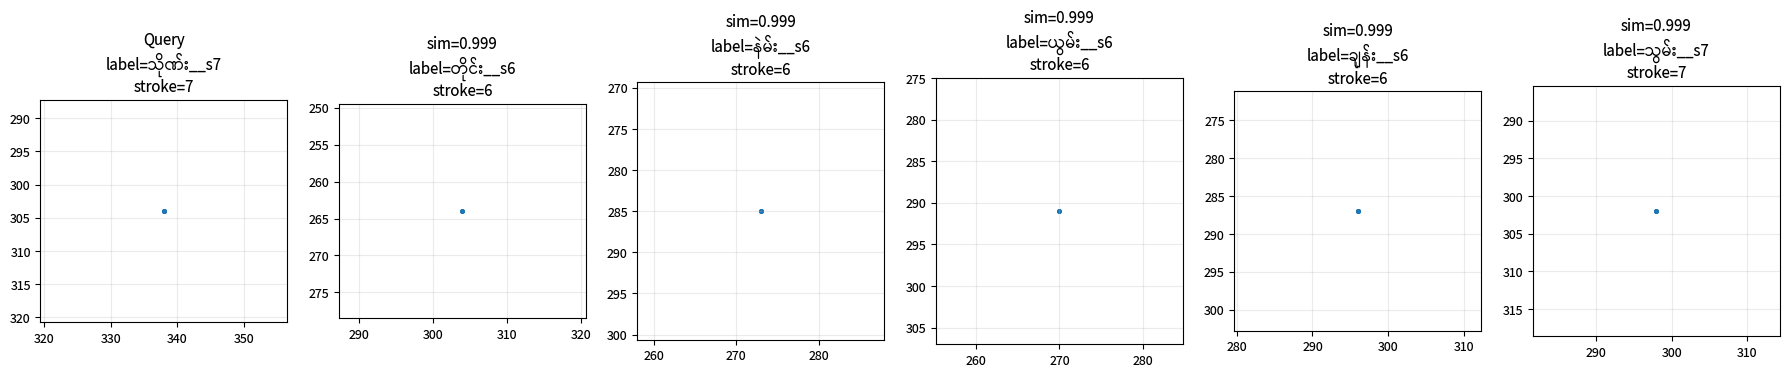

(<Figure size 1800x400 with 6 Axes>,
 array([<Axes: title={'center': 'Query\nlabel=သိုဏ်း__s7\nstroke=7'}>,
        <Axes: title={'center': 'sim=0.999\nlabel=တိုင်း__s6\nstroke=6'}>,
        <Axes: title={'center': 'sim=0.999\nlabel=နဲမ်း__s6\nstroke=6'}>,
        <Axes: title={'center': 'sim=0.999\nlabel=ယွမ်း__s6\nstroke=6'}>,
        <Axes: title={'center': 'sim=0.999\nlabel=ချုန်း__s6\nstroke=6'}>,
        <Axes: title={'center': 'sim=0.999\nlabel=သွမ်း__s7\nstroke=7'}>],
       dtype=object))

In [17]:
plot_query_neighbors(
    full_emb_df,
    X24,
    query_idx=random.randrange(1,len(full_emb_df),1),
    top_k=5,
    strokes_col="cleaned_strokes",
    label_col="embedding_label",
)

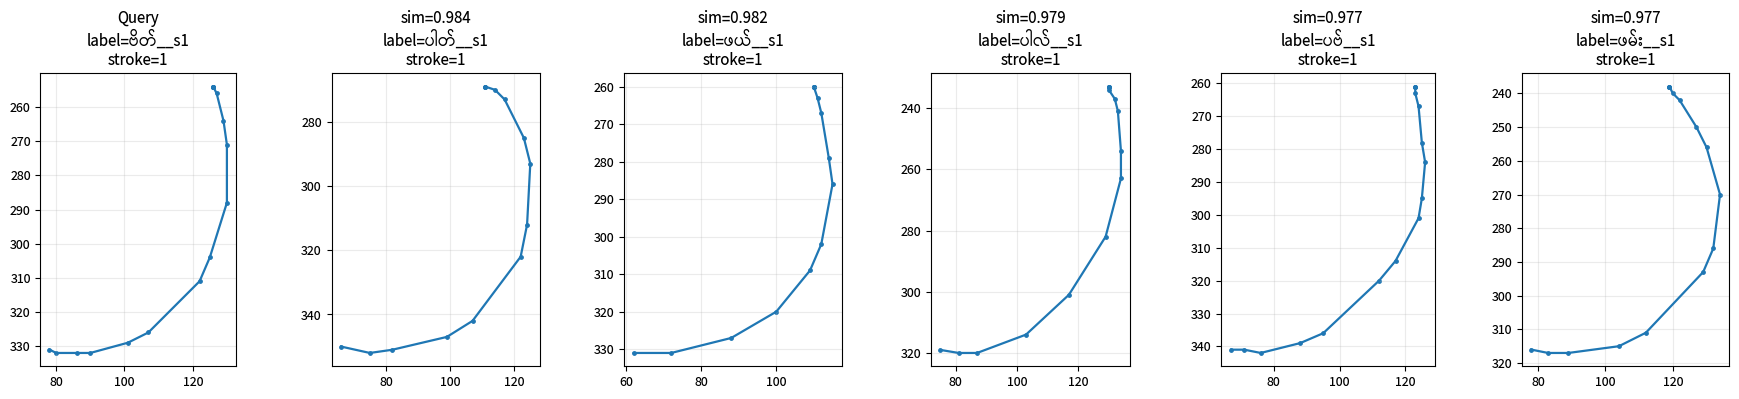

(<Figure size 1800x400 with 6 Axes>,
 array([<Axes: title={'center': 'Query\nlabel=ဗိတ်__s1\nstroke=1'}>,
        <Axes: title={'center': 'sim=0.984\nlabel=ပါတ်__s1\nstroke=1'}>,
        <Axes: title={'center': 'sim=0.982\nlabel=ဖယ်__s1\nstroke=1'}>,
        <Axes: title={'center': 'sim=0.979\nlabel=ပါလ်__s1\nstroke=1'}>,
        <Axes: title={'center': 'sim=0.977\nlabel=ပဗ်__s1\nstroke=1'}>,
        <Axes: title={'center': 'sim=0.977\nlabel=ဖမ်း__s1\nstroke=1'}>],
       dtype=object))

In [18]:
plot_query_neighbors(
    full_emb_df,
    X24,
    query_idx=random.randrange(1,len(full_emb_df),1),
    top_k=5,
    strokes_col="cleaned_strokes",
    label_col="embedding_label",
)

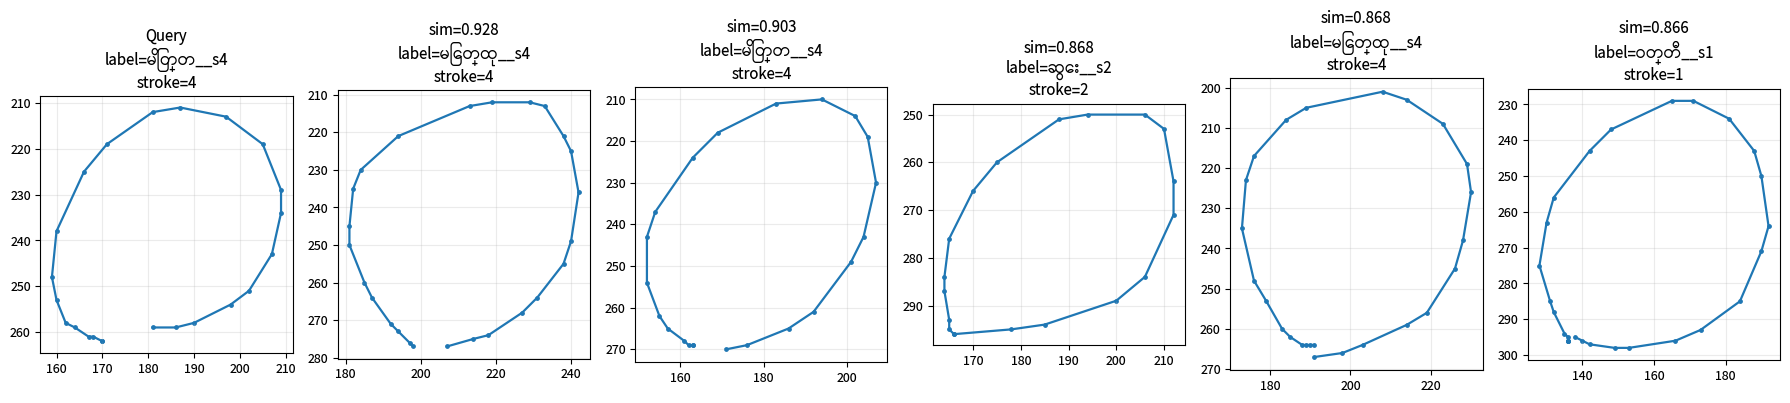

(<Figure size 1800x400 with 6 Axes>,
 array([<Axes: title={'center': 'Query\nlabel=မြိတ္တ__s4\nstroke=4'}>,
        <Axes: title={'center': 'sim=0.928\nlabel=မြေတ္ထု__s4\nstroke=4'}>,
        <Axes: title={'center': 'sim=0.903\nlabel=မြိတ္တ__s4\nstroke=4'}>,
        <Axes: title={'center': 'sim=0.868\nlabel=ဆွေး__s2\nstroke=2'}>,
        <Axes: title={'center': 'sim=0.868\nlabel=မြေတ္ထု__s4\nstroke=4'}>,
        <Axes: title={'center': 'sim=0.866\nlabel=ဝတ္တီ__s1\nstroke=1'}>],
       dtype=object))

In [19]:
plot_query_neighbors(
    full_emb_df,
    X24,
    query_idx=random.randrange(1,len(full_emb_df),1),
    top_k=5,
    strokes_col="cleaned_strokes",
    label_col="embedding_label",
)

In [23]:
sid = processed_df["sample_index"].iloc[0]

print("Sample index:", sid)
print("Target syllable:",
      processed_df.loc[processed_df["sample_index"] == sid, "syllable"].iloc[0])


display(
    full_emb_df.loc[full_emb_df["sample_index"] == sid,
                         ["sample_index", "stroke_index", "embedding"]]
)

Sample index: 0
Target syllable: အ


,sample_index,stroke_index,embedding
0,0,0,"[-0.02572239, 0.0014807043, 0.03872868, 0.0460..."
1,0,1,"[0.021021098, -0.0018215858, 0.038095046, 0.04..."
